In [1376]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [1377]:
# Load Data
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')
joblib.dump(df, '../df_original.pkl')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,94,High,Junior Level,Sales Executive,Very High,Single,5993,19479,8,Yes,11,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,61,Medium,Junior Level,Research Scientist,Medium,Married,5130,24907,1,No,23,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,92,Medium,Entry Level,Laboratory Technician,High,Single,2090,2396,6,Yes,15,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,56,High,Entry Level,Research Scientist,High,Married,2909,23159,1,Yes,11,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,40,High,Entry Level,Laboratory Technician,Medium,Married,3468,16632,9,No,12,Excellent,Very High,1,6,3,Better,2,2,2,2


In [1378]:
# Encode
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop(columns='Attrition')
y = df['Attrition']

In [1379]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [1380]:
pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                solver='liblinear',
                max_iter=2000,
                random_state=42
            ))
        ])
pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

In [1381]:
param_grid = {
    'model__C': [0.01, 0.1,0.4, 0.5, 1, 5]
}
        
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)
        
grid.fit(X_train, y_train)

/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=2000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 0.4, 0.5, 1, 5]},
             scoring='f1')

In [1382]:
pipeline = grid.best_estimator_
        
print(f"Best C: {grid.best_params_['model__C']}")

Best C: 0.4


In [1383]:
threshold = 0.62
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.4, class_weight='balanced',
                                    max_iter=2000, random_state=42,
                                    solver='liblinear'))])

In [1409]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.626).astype(int)

In [1410]:
print("\n── Evaluation ──")
print(classification_report(y_test, y_pred))


── Evaluation ──
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       370
           1       0.51      0.66      0.58        71

    accuracy                           0.84       441
   macro avg       0.72      0.77      0.74       441
weighted avg       0.86      0.84      0.85       441



In [1386]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC: 0.8327


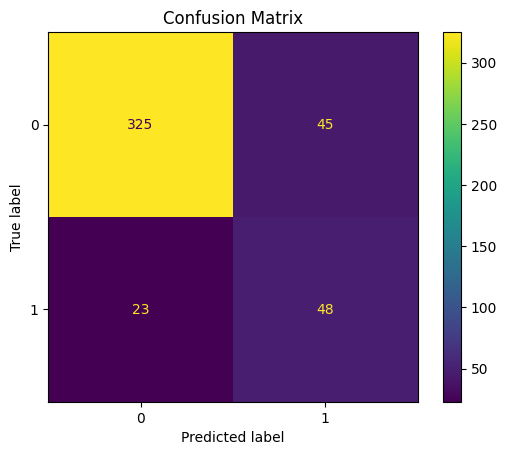

In [1387]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

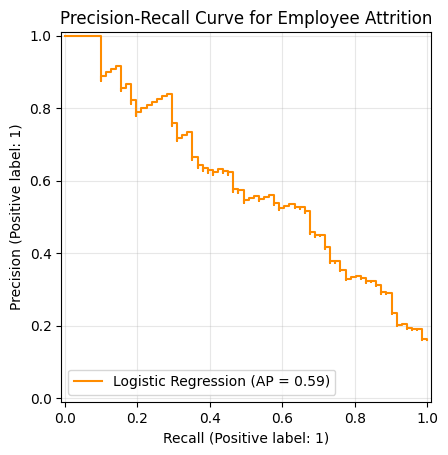

In [1388]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Using the y_test and y_proba from your existing code
display = PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_proba, 
    name="Logistic Regression",
    color="darkorange" # You can customize the line color
)

# Customize the plot
plt.title("Precision-Recall Curve for Employee Attrition")
plt.grid(alpha=0.3) # Adds a light grid for readability
plt.show()